In [21]:
!pip3 install stable-baselines3[extra]

In [31]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random


class SimulatedPod:
    def __init__(self):
        self.health = "healthy"
        self.cpu = 0.0
        self.memory = random.uniform(0.1, 0.3)
        self.latency = 50.0
        self.error_rate = 0.001
        self.restart_timer = 0

    def update(self, requests_per_pod):

        if self.health == "restarting":
            self.restart_timer -= 1
            if self.restart_timer <= 0:
                self.health = "healthy"
                self.cpu = 0.0
                self.memory = random.uniform(0.1, 0.3)
                self.latency = 50.0
                self.error_rate = 0.001
            return

        if self.health == "crashed":
            self.cpu = 0.0
            self.latency = 0.0
            self.error_rate = 1.0
            return

        # CPU load
        self.cpu = min(1.0, requests_per_pod * 0.005)

        # Memory leak
        if self.cpu > 0.7:
            self.memory = min(1.0, self.memory + 0.01)

        # Latency
        if self.cpu > 0.8:
            self.latency = 50 + (self.cpu - 0.8) * 1000
        else:
            self.latency = 50

        # Errors
        if self.cpu > 0.9 or self.memory > 0.9:
            self.health = "degraded"
            self.error_rate = 0.05 + (max(self.cpu, self.memory) - 0.9) * 0.5
        elif self.health == "degraded" and self.cpu < 0.6 and self.memory < 0.6:
            self.health = "healthy"
            self.error_rate = 0.001


class KubernetesRLEnv(gym.Env):

    metadata = {'render_modes': ['console']}

    def __init__(self):
        super().__init__()

        self.max_pods = 10
        self.min_pods = 1
        self.max_steps = 200

        self.action_space = spaces.Discrete(4)

        self.observation_space = spaces.Box(
            low=0.0, high=np.inf, shape=(9,), dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.pods = [SimulatedPod() for _ in range(3)]
        self.current_step = 0
        self.request_rate = 100
        self.time_since_failure = 0
        self.last_action = None

        return self._get_observation(), {}

    def _inject_failures(self):
        if random.random() < 0.02:
            self.request_rate = random.randint(300, 500)
        else:
            self.request_rate = max(50, self.request_rate + random.randint(-20, 20))

        for pod in self.pods:
            if pod.health == "healthy":
                if random.random() < 0.01:
                    pod.health = "crashed"
                    self.time_since_failure = 0

    def step(self, action):
        self.current_step += 1
        self.time_since_failure += 1
        reward = 0

        # ---- ACTION ----
        if action == 1:
            restarted = False
            for pod in self.pods:
                if pod.health in ["crashed", "degraded"]:
                    pod.health = "restarting"
                    pod.restart_timer = 3
                    reward -= 1
                    restarted = True
                    break
            if not restarted:
                reward -= 3

        elif action == 2:
            if len(self.pods) < self.max_pods:
                self.pods.append(SimulatedPod())
                reward -= 1

        elif action == 3:
            if len(self.pods) > self.min_pods:
                self.pods.pop()
                reward -= 1

        # ---- LOAD ----
        self._inject_failures()

        active_pods = [p for p in self.pods if p.health not in ["crashed", "restarting"]]
        num_active = len(active_pods) if active_pods else 1
        requests_per_pod = self.request_rate / num_active

        for pod in self.pods:
            pod.update(requests_per_pod)

        # ---- OBS ----
        obs = self._get_observation()
        healthy, degraded, crashed = obs[0], obs[1], obs[2]
        avg_cpu, avg_mem = obs[3], obs[4]

        # ---- REWARD ----

        # Failures
        if crashed > 0:
            reward -= 25 * crashed
        if crashed == len(self.pods):
            reward -= 100

        # Pre-failure signals
        if avg_cpu > 0.85:
            reward -= (avg_cpu - 0.85) * 15
        if avg_mem > 0.9:
            reward -= 10

        # Degradation
        reward -= 2 * degraded

        # Ideal
        if healthy == len(self.pods) and avg_cpu < 0.7:
            reward += 10

        # Action shaping
        if action == 0 and healthy == len(self.pods):
            reward += 1.5

        if action == 1 and avg_cpu > 0.7:
            reward -= 2

        if action == 2 and avg_cpu > 0.7:
            reward += 2

        if action == 3 and avg_cpu < 0.3:
            reward += 2

        if healthy == len(self.pods) and avg_cpu < 0.7:
            if action in [2, 3]:
                reward -= 2

        # ---- FINAL FIXED COST MODEL ----

        optimal_pods = max(1, self.request_rate / 100)
        safe_pods = optimal_pods * 1.2

        # Base cost
        reward -= 0.5 * (len(self.pods) / self.max_pods)

        # Over-scaling
        if len(self.pods) > safe_pods:
            reward -= (len(self.pods) - safe_pods) * 2

        # Under-scaling
        if len(self.pods) < optimal_pods:
            reward -= (optimal_pods - len(self.pods)) * 4

        # CPU safety
        if avg_cpu > 0.75:
            reward -= (avg_cpu - 0.75) * 10

        # Anti-oscillation
        if self.last_action is not None:
            if action in [2, 3] and self.last_action in [2, 3] and action != self.last_action:
                reward -= 0.5

        self.last_action = action

        # ---- DONE ----
        terminated = bool(crashed == len(self.pods) and len(self.pods) > 0)
        truncated = bool(self.current_step >= self.max_steps)

        return obs, reward, terminated, truncated, {"request_rate": self.request_rate}

    def _get_observation(self):
        healthy = sum(1 for p in self.pods if p.health == "healthy")
        degraded = sum(1 for p in self.pods if p.health == "degraded")
        crashed = sum(1 for p in self.pods if p.health == "crashed")

        active_pods = [p for p in self.pods if p.health not in ["crashed", "restarting"]]

        if not active_pods:
            avg_cpu, avg_mem, avg_lat, avg_err = 0.0, 0.0, 0.0, 1.0
        else:
            avg_cpu = sum(p.cpu for p in active_pods) / len(active_pods)
            avg_mem = sum(p.memory for p in active_pods) / len(active_pods)
            avg_lat = sum(p.latency for p in active_pods) / len(active_pods)
            avg_err = sum(p.error_rate for p in active_pods) / len(active_pods)

        return np.array([
            healthy,
            degraded,
            crashed,
            avg_cpu,
            avg_mem,
            avg_lat / 1000.0,
            avg_err,
            self.time_since_failure / self.max_steps,
            len(self.pods) / self.max_pods
        ], dtype=np.float32)

## Agent Training


In [32]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor

## logss
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

# initialize and wrap the environment
env = KubernetesRLEnv()
env = Monitor(env, log_dir)

# verify the environment follows gym api
# print("Checking environment...")
# check_env(env)
# print("Environment check passed!")


model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    tensorboard_log=log_dir
)


print("Training started.")
timesteps = 50000
model.learn(total_timesteps=timesteps, progress_bar=False)


model_path = "ppo_kubernetes_recovery"
model.save(model_path)
print(f"Model saved to {model_path}.zip")

Using cpu device
Wrapping the env in a DummyVecEnv.
Training started.
Logging to ./logs/PPO_7
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 190       |
|    ep_rew_mean     | -1.37e+03 |
| time/              |           |
|    fps             | 1299      |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 185         |
|    ep_rew_mean          | -1.17e+03   |
| time/                   |             |
|    fps                  | 721         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012290493 |
|    clip_fraction        | 0.0773      |
|    clip_range           | 0.2         |
|    entro

In [33]:
import numpy as np
from stable_baselines3 import PPO

def evaluate_policy(env, model, episodes=5):

    total_rewards = []

    for ep in range(episodes):
        obs, _ = env.reset()
        done = False
        truncated = False
        ep_reward = 0
        step_count = 0

        print(f"\n--- Episode {ep+1} ---")

        while not (done or truncated):
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            ep_reward += reward
            step_count += 1


            action_names = ["No-op", "Restart Pod", "Scale Up", "Scale Down"]
            if action != 0:
                print(f"Step {step_count}: Took action -> {action_names[action]}")
                print(f"State: {int(obs[0])} Healthy, {int(obs[2])} Crashed | CPU: {obs[3]:.2f} | Replicas: {int(obs[8]*10)}")

        total_rewards.append(ep_reward)
        print(f"Episode {ep+1} finished after {step_count} steps. Total Reward: {ep_reward:.2f}")

    print(f"\nAverage Reward over {episodes} episodes: {np.mean(total_rewards):.2f}")

#evaluvate
env = KubernetesRLEnv()
try:
    model = PPO.load("ppo_kubernetes_recovery")
    print("Trained model loaded successfully.")
    evaluate_policy(env, model, episodes=5)
except Exception as e:
    print(f"Could not load model. Ensure you have trained it first. Error: {e}")

Trained model loaded successfully.

--- Episode 1 ---
Step 10: Took action -> Restart Pod
State: 2 Healthy, 0 Crashed | CPU: 0.23 | Replicas: 3
Step 30: Took action -> Scale Up
State: 1 Healthy, 1 Crashed | CPU: 0.71 | Replicas: 4
Step 31: Took action -> Restart Pod
State: 0 Healthy, 1 Crashed | CPU: 1.00 | Replicas: 4
Step 32: Took action -> Scale Up
State: 1 Healthy, 1 Crashed | CPU: 0.70 | Replicas: 5
Step 33: Took action -> Restart Pod
State: 1 Healthy, 1 Crashed | CPU: 0.67 | Replicas: 5
Step 34: Took action -> Restart Pod
State: 1 Healthy, 0 Crashed | CPU: 0.66 | Replicas: 5
Step 35: Took action -> Scale Up
State: 5 Healthy, 0 Crashed | CPU: 0.38 | Replicas: 6
Step 46: Took action -> Restart Pod
State: 5 Healthy, 0 Crashed | CPU: 0.40 | Replicas: 6
Step 110: Took action -> Restart Pod
State: 5 Healthy, 0 Crashed | CPU: 0.40 | Replicas: 6
Step 129: Took action -> Restart Pod
State: 5 Healthy, 0 Crashed | CPU: 0.33 | Replicas: 6
Step 134: Took action -> Restart Pod
State: 5 Healthy

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def plot_agent_behavior(env, model, max_steps=200, save_path="agent_behavior.png"):
    # Run one episode and plot pod Health, CPU Usage, and Scaling Actions over time
    obs, _ = env.reset()
    done = False
    truncated = False

    steps, healthy_counts, crashed_counts, cpu_usages, replica_counts, actions_taken = [], [], [], [], [], []
    step_count = 0

    print("Running simulation for plotting...")
    while not (done or truncated) and step_count < max_steps:
        action, _states = model.predict(obs, deterministic=True)

        steps.append(step_count)
        healthy_counts.append(obs[0])
        crashed_counts.append(obs[2])
        cpu_usages.append(obs[3])
        replica_counts.append(obs[8] * env.max_pods)
        actions_taken.append(action)

        obs, reward, done, truncated, info = env.step(action)
        step_count += 1

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle('Agent Recovery Behavior', fontsize=16)

    ax1.plot(steps, healthy_counts, label='Healthy Pods', color='green', linewidth=2)
    ax1.plot(steps, crashed_counts, label='Crashed Pods', color='red', linewidth=2, linestyle='--')
    ax1.set_ylabel('Number of Pods')
    ax1.set_title('Pod Health Over Time')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2.plot(steps, cpu_usages, label='Avg CPU Usage', color='orange', linewidth=2)
    ax2.axhline(y=0.8, color='red', linestyle=':', label='Overload Threshold (80%)')
    ax2.set_ylabel('Normalized CPU (0 to 1)')
    ax2.set_title('System Load (Spikes indicate failure injection)')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    ax3.step(steps, replica_counts, label='Total Replicas', color='blue', where='post')

    action_colors = {1: 'purple', 2: 'green', 3: 'red'}
    action_labels_map = {1: 'Restart Pod', 2: 'Scale Up', 3: 'Scale Down'}
    added_labels = set()

    for i, act in enumerate(actions_taken):
        if act != 0:
            current_label = action_labels_map[act]
            if current_label not in added_labels:
                ax3.scatter(steps[i], replica_counts[i], color=action_colors[act], zorder=5, s=50, label=current_label)
                added_labels.add(current_label)
            else:
                ax3.scatter(steps[i], replica_counts[i], color=action_colors[act], zorder=5, s=50)

    ax3.set_ylabel('Replica Count')
    ax3.set_xlabel('Timesteps')
    ax3.set_title('Agent Actions & Auto-Scaling')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Plot saved successfully to {save_path}")
    plt.show()

def plot_training_results(log_dir="./logs/"):
    ## Reads Monitor logs and plots Reward and Episode Length
    monitor_file = os.path.join(log_dir, "monitor.csv")
    if not os.path.exists(monitor_file):
        monitor_file = os.path.join(log_dir, "0.monitor.csv")

    if not os.path.exists(monitor_file):
        print(f"Could not find monitor.csv in {log_dir}.")
        return

    df = pd.read_csv(monitor_file, skiprows=1)
    df['cumulative_steps'] = df['l'].cumsum()
    window = min(50, len(df))
    df['rolling_reward'] = df['r'].rolling(window=window).mean()
    df['rolling_length'] = df['l'].rolling(window=window).mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle('RL Agent Training Convergence', fontsize=16)

    ax1.plot(df['cumulative_steps'], df['r'], alpha=0.3, color='blue', label='Raw Reward')
    ax1.plot(df['cumulative_steps'], df['rolling_reward'], color='darkblue', linewidth=2, label=f'{window}-Ep Moving Avg')
    ax1.set_ylabel('Episode Reward')
    ax1.set_title('Learning Curve (Reward vs Timesteps)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(df['cumulative_steps'], df['l'], alpha=0.3, color='green', label='Raw Length')
    ax2.plot(df['cumulative_steps'], df['rolling_length'], color='darkgreen', linewidth=2, label=f'{window}-Ep Moving Avg')
    ax2.set_ylabel('Episode Length (Steps)')
    ax2.set_xlabel('Total Timesteps')
    ax2.set_title('Survival Time (Episode Length vs Timesteps)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_convergence.png")
    plt.show()

def plot_tensorboard_losses(log_dir="./logs/"):
    """Reads TensorBoard event files and plots the neural network losses."""
    subdirs = [os.path.join(log_dir, d) for d in os.listdir(log_dir) if os.path.isdir(os.path.join(log_dir, d))]
    if not subdirs:
        print(f"No subdirectories found in {log_dir}.")
        return

    latest_run_dir = max(subdirs, key=os.path.getmtime)
    print(f"Loading TensorBoard logs from: {latest_run_dir}")

    ea = EventAccumulator(latest_run_dir, size_guidance={'scalars': 0})
    ea.Reload()

    available_metrics = ea.Tags().get('scalars', [])
    if 'train/value_loss' not in available_metrics or 'train/policy_gradient_loss' not in available_metrics:
        print("Loss metrics not found in logs.")
        return

    try:
        val_loss_events = ea.Scalars('train/value_loss')
        pg_loss_events = ea.Scalars('train/policy_gradient_loss')
        entropy_loss_events = ea.Scalars('train/entropy_loss')

        steps = [x.step for x in val_loss_events]
        val_loss = [x.value for x in val_loss_events]
        pg_loss = [x.value for x in pg_loss_events]
        entropy = [x.value for x in entropy_loss_events]

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
        fig.suptitle('PPO Neural Network Losses', fontsize=16)

        ax1.plot(steps, val_loss, color='orange', alpha=0.8)
        ax1.set_title('Value Loss (Critic Network Error)')
        ax1.set_ylabel('Loss')
        ax1.grid(True, alpha=0.3)

        ax2.plot(steps, pg_loss, color='purple', alpha=0.8)
        ax2.set_title('Policy Gradient Loss (Actor Network Updates)')
        ax2.set_ylabel('Loss')
        ax2.grid(True, alpha=0.3)

        ax3.plot(steps, entropy, color='teal', alpha=0.8)
        ax3.set_title('Entropy Loss (Exploration vs Exploitation)')
        ax3.set_xlabel('Total Timesteps')
        ax3.set_ylabel('Entropy')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("ppo_losses.png")
        plt.show()

    except Exception as e:
        print(f"An error occurred while plotting: {e}")

Running simulation for plotting...
Make sure model is trained first. Error: unhashable type: 'numpy.ndarray'


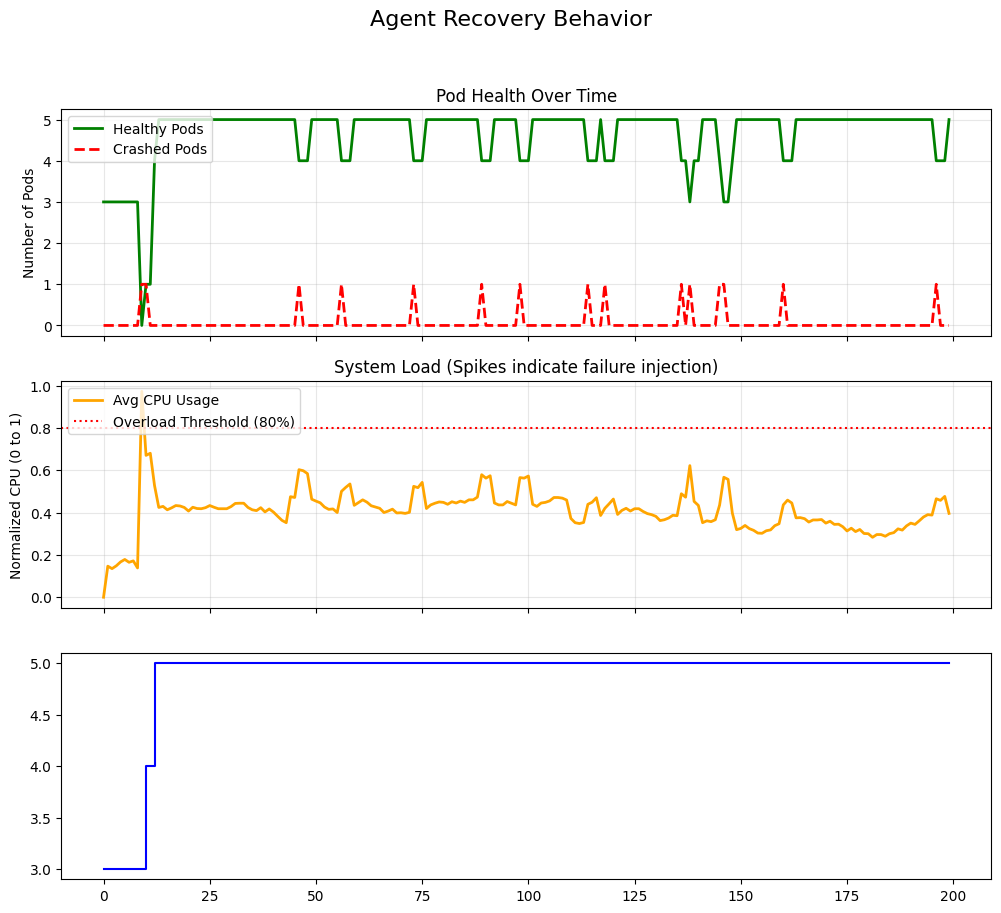

In [35]:

try:
    plot_agent_behavior(env, model, save_path="agent_recovery_plot.png")
    plot_training_results()
    plot_tensorboard_losses()
except Exception as e:
    print(f"Make sure model is trained first. Error: {e}")

In [36]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)


env = KubernetesRLEnv()
env = Monitor(env, log_dir)

# vectorize and normalize
vec_env = DummyVecEnv([lambda: env])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=10.)


policy_kwargs = dict(net_arch=dict(pi=[64, 64], vf=[128, 128]))

# fine tuned ppo
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    learning_rate=3e-4,
    ent_coef=0.02,
    vf_coef=0.5,
    clip_range=0.2,
    policy_kwargs=policy_kwargs,
    tensorboard_log=log_dir
)

print("Starting fine tuned hardened training...")
timesteps = 50000
model.learn(total_timesteps=timesteps, progress_bar=True)


model_path = "ppo_kubernetes_hardened"
model.save(model_path)
vec_env.save(os.path.join(log_dir, "vec_normalize.pkl"))
print(f"Model and Normalization stats saved to {model_path}.zip and logs/")

Using cpu device
Starting fine tuned hardened training...
Logging to ./logs/PPO_8


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 186       |
|    ep_rew_mean     | -1.06e+03 |
| time/              |           |
|    fps             | 898       |
|    iterations      | 1         |
|    time_elapsed    | 2         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 193         |
|    ep_rew_mean          | -955        |
| time/                   |             |
|    fps                  | 608         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010985075 |
|    clip_fraction        | 0.121       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.149      |
|    learning_rate  

Model and Normalization stats saved to ppo_kubernetes_hardened.zip and logs/


In [37]:
import os
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

base_env = KubernetesRLEnv()

vec_env = DummyVecEnv([lambda: base_env])
#load
stats_path = os.path.join("./logs/", "vec_normalize.pkl")
try:
    vec_env = VecNormalize.load(stats_path, vec_env)
    vec_env.training = False
    vec_env.norm_reward = False
    print("Normalization statistics loaded successfully.")
except Exception as e:
    print(f"Could not load normalization stats. Error: {e}")

try:
    hardened_model = PPO.load("ppo_kubernetes_hardened")
    print("Hardened model loaded successfully.")

    # eval..
    episodes = 5
    total_rewards = []

    for ep in range(episodes):
        obs = vec_env.reset() # vecenv returns a batched observation
        done = False
        ep_reward = 0
        step_count = 0

        print(f"\n--- Episode {ep+1} ---")

        while not done:
            action, _states = hardened_model.predict(obs, deterministic=True)
            obs, reward, done, info = vec_env.step(action)

            ep_reward += reward[0] # reward is also batched
            step_count += 1

            if action[0] != 0:
                action_names = ["No-op", "Restart Pod", "Scale Up", "Scale Down"]
                print(f"Step {step_count}: Took action -> {action_names[action[0]]}")

        total_rewards.append(ep_reward)
        print(f"Episode {ep+1} finished after {step_count} steps. Total Reward: {ep_reward:.2f}")

    print(f"\nAverage Reward over {episodes} episodes: {np.mean(total_rewards):.2f}")

except Exception as e:
    print(f"Could not load model. Error: {e}")

Normalization statistics loaded successfully.
Hardened model loaded successfully.

--- Episode 1 ---
Step 1: Took action -> Scale Down
Step 2: Took action -> Restart Pod
Step 3: Took action -> Restart Pod
Step 4: Took action -> Restart Pod
Step 5: Took action -> Restart Pod
Step 6: Took action -> Restart Pod
Step 16: Took action -> Restart Pod
Step 17: Took action -> Restart Pod
Step 20: Took action -> Restart Pod
Step 21: Took action -> Scale Up
Step 22: Took action -> Restart Pod
Step 23: Took action -> Scale Down
Step 24: Took action -> Restart Pod
Step 25: Took action -> Restart Pod
Step 26: Took action -> Restart Pod
Step 27: Took action -> Restart Pod
Step 28: Took action -> Restart Pod
Step 29: Took action -> Restart Pod
Step 30: Took action -> Restart Pod
Step 31: Took action -> Restart Pod
Step 32: Took action -> Restart Pod
Step 33: Took action -> Restart Pod
Step 34: Took action -> Restart Pod
Step 35: Took action -> Restart Pod
Step 36: Took action -> Restart Pod
Step 37: T

Plot saved as simple_learning_curve.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


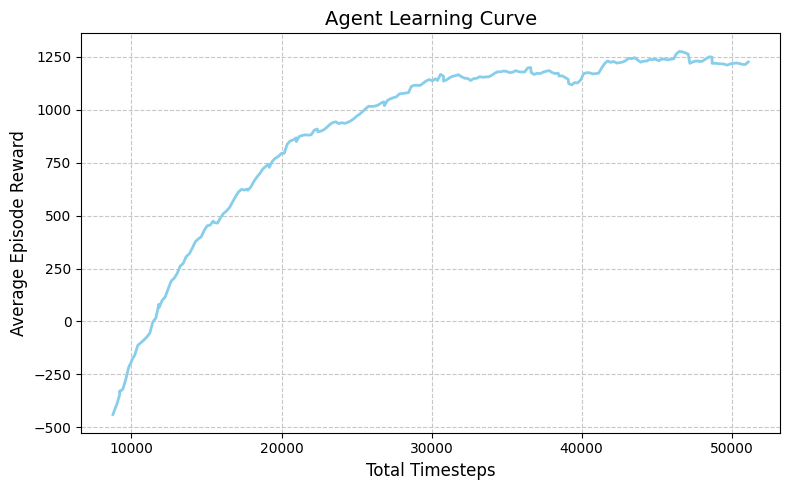

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the training logs (skipping the first comment line)
df = pd.read_csv("./logs/monitor.csv", skiprows=1)

# 2. Calculate cumulative timesteps for the x-axis
df['timesteps'] = df['l'].cumsum()

# 3. Calculate a moving average of the rewards to smooth the curve
df['smoothed_reward'] = df['r'].rolling(window=50).mean()

# 4. Create a simple, clean plot
plt.figure(figsize=(8, 5))
plt.plot(df['timesteps'], df['smoothed_reward'], color='skyblue', linewidth=2)

# Add basic labels
plt.title("Agent Learning Curve", fontsize=14)
plt.xlabel("Total Timesteps", fontsize=12)
plt.ylabel("Average Episode Reward", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save and show
plt.tight_layout()
plt.savefig("simple_learning_curve.png", dpi=300)
print("Plot saved as simple_learning_curve.png")
plt.show()

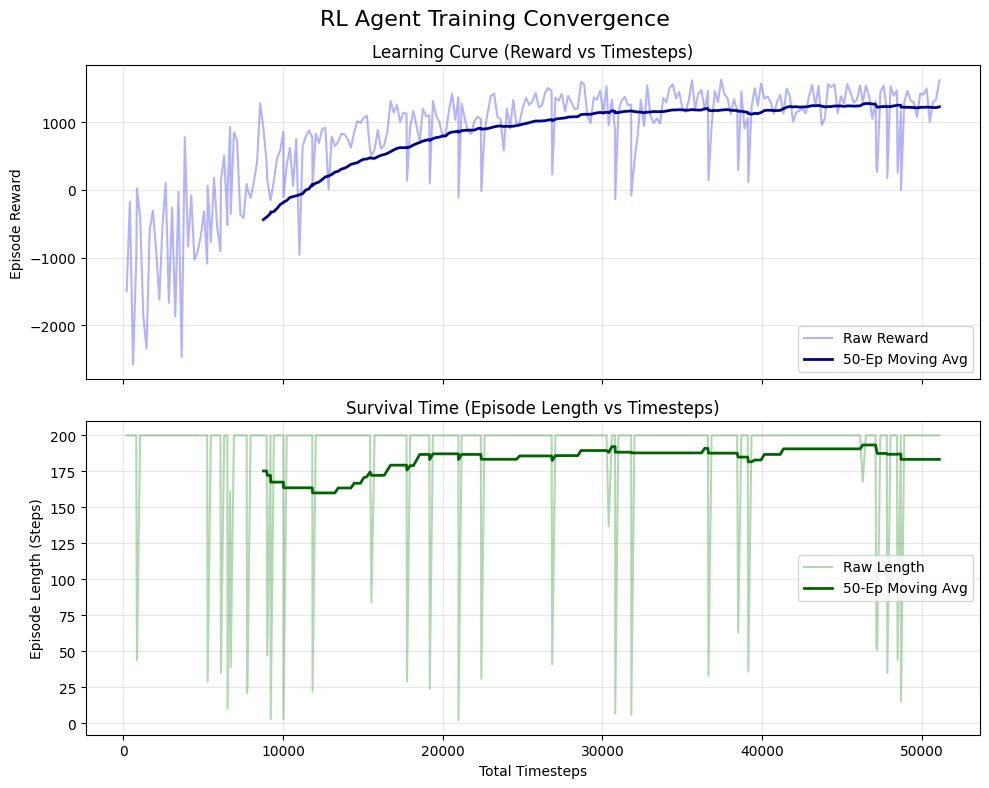

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3.common import results_plotter

def plot_training_results(log_dir="./logs/"):

    monitor_file = os.path.join(log_dir, "monitor.csv")

    if not os.path.exists(monitor_file):
        monitor_file = os.path.join(log_dir, "0.monitor.csv")

    if not os.path.exists(monitor_file):
        print(f"Could not find monitor.csv in {log_dir}.")
        return

    df = pd.read_csv(monitor_file, skiprows=1)

    df['cumulative_steps'] = df['l'].cumsum()

    # calculate rolling averages to smooth out the noisy RL data
    window = min(50, len(df)) # 50 episode rolling window
    df['rolling_reward'] = df['r'].rolling(window=window).mean()
    df['rolling_length'] = df['l'].rolling(window=window).mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle('RL Agent Training Convergence', fontsize=16)

    # rewards
    ax1.plot(df['cumulative_steps'], df['r'], alpha=0.3, color='blue', label='Raw Reward')
    ax1.plot(df['cumulative_steps'], df['rolling_reward'], color='darkblue', linewidth=2, label=f'{window}-Ep Moving Avg')
    ax1.set_ylabel('Episode Reward')
    ax1.set_title('Learning Curve (Reward vs Timesteps)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # eps len
    ax2.plot(df['cumulative_steps'], df['l'], alpha=0.3, color='green', label='Raw Length')
    ax2.plot(df['cumulative_steps'], df['rolling_length'], color='darkgreen', linewidth=2, label=f'{window}-Ep Moving Avg')
    ax2.set_ylabel('Episode Length (Steps)')
    ax2.set_xlabel('Total Timesteps')
    ax2.set_title('Survival Time (Episode Length vs Timesteps)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_convergence.png")

    plt.show()

if __name__ == "__main__":
    plot_training_results()